# CardioRisk Prediction

## Problem Statement

CardioCare, a healthcare provider, is committed to enhancing preventative care and improving patient outcomes. With the growing prevalence of cardiovascular disease (CVD), accurate and timely risk assessment is essential. Although CardioCare might provide comprehensive medical resources, optimising doctors' valuable consultation time is crucial for efficient and effective care. At the same time, correctly identifying at-risk patients is highly important.

### Business Objective

CardioCare aims to develop a machine learning model to predict CVD risk using patient health data. This model is intended to support healthcare providers in efficiently allocating resources and optimising doctors' consultation time. By identifying patients with high risk of CVD, the model can help prioritise consultations and potentially eliminate the need for an initial consultation stage for some patients. This will allow doctors to focus their expertise on individuals requiring immediate attention.

### Assignment Tasks

You need to perform the following steps to complete this assignment:
1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis
4. Train Validation Split
5. Feature Engineering
6. Model Building
8. Prediction and Model Evaluation

**Based on this assignment, you have to answer the following questions:**

- What insights can we gain from exploring the relationships between different health metrics and the prevalence of cardiovascular disease within the patient population?

- Based on the analysis, which patient characteristics emerge as the strongest predictors of cardiovascular disease risk? Are there any surprising or unexpected findings?

- How effectively can machine learning models identify individuals at risk of developing cardiovascular disease based on their health data? How does the evaluation results vary across different models?

- How can CardioCare integrate the predictive model into their existing healthcare workflows to enhance preventative care strategies?

### Data Dictionary

The CardioRisk Prediction has 14 Columns and 70000 Rows. Following data dictionary provides the description for each column present in dataset:


<table>
  <tr>
    <th>Column Name</th>
    <th>Description</th>
  </tr>
  <tr>
    <td>Unnamed: 0</td>
    <td>Index or row number</td>
  </tr>
  <tr>
    <td>id</td>
    <td>Unique identifier for each individual in the dataset</td>
  </tr>
  <tr>
    <td>age</td>
    <td>Age of the individual, measured in days</td>
  </tr>
  <tr>
    <td>gender</td>
    <td>Gender of the individual (1: Female, 2: Male)</td>
  </tr>
  <tr>
    <td>height</td>
    <td>Height of the individual, measured in centimeters</td>
  </tr>
  <tr>
    <td>weight</td>
    <td>Weight of the individual, measured in kilograms</td>
  </tr>
  <tr>
    <td>ap_hi</td>
    <td>Systolic blood pressure reading</td>
  </tr>
  <tr>
    <td>ap_lo</td>
    <td>Diastolic blood pressure reading</td>
  </tr>
  <tr>
    <td>cholesterol</td>
    <td>Cholesterol level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>gluc</td>
    <td>Glucose level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>smoke</td>
    <td>Smoking status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>alco</td>
    <td>Alcohol intake status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>active</td>
    <td>Physical activity status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>cardio</td>
    <td>Presence or absence of cardiovascular disease (0: No Disease, 1: Disease)</td>
  </tr>
</table>

</body>
</html>


    
This data dictionary serves as a reference for understanding the dataset and its variables.

## **1. Data Understanding** 

<font color = red>[2 marks]</font> <br>

In this stage, you have to load the dataset and check basic statistics of the data, including preview of data, dimension of data, column descriptions and data types.

In [1]:
# suggested imports; import more libraries as needed
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, \
    confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

### **1.1 Load the dataset**

<font color = red>[2 marks]</font> <br>

In [2]:
import os
print(os.getcwd())

C:\Users\Admin


In [3]:
# Load the dataset
df = pd.read_csv("C:/Users/Admin/OneDrive/Desktop/upgrad/cardio vascular disease project/Starter Files and Dataset/health_data.csv")
print(df.head())

   Unnamed: 0   id      age  gender  height  weight  ap_hi  ap_lo  \
0           0  0.0  18393.0       1   168.0    62.0  110.0   80.0   
1           1  1.0  20228.0       0   156.0    85.0  140.0   90.0   
2           2  2.0  18857.0       0   165.0    64.0  130.0   70.0   
3           3  3.0  17623.0       1   169.0    82.0  150.0  100.0   
4           4  4.0  17474.0       0   156.0    56.0  100.0   60.0   

   cholesterol  gluc  smoke  alco  active  cardio  
0            0     0      0     0       1       0  
1            2     0      0     0       1       1  
2            2     0      0     0       0       1  
3            0     0      0     0       1       1  
4            0     0      0     0       0       0  


#### **1.1.1** Check the first few entries

In [4]:
# Check the first few entries
df.shape

(70000, 14)

In [5]:
df.columns


Index(['Unnamed: 0', 'id', 'age', 'gender', 'height', 'weight', 'ap_hi',
       'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

#### **1.1.2** Remove columns which are irrelevant <font color = red>[2 marks]</font> <br>

In [6]:
# Remove irrelevant columns like unique identifiers or index
df = df.drop("Unnamed: 0", axis=1)

In [7]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

#### **1.1.3** Inspect the shape of the dataset

In [8]:
# Inspect the shape of the dataset
df.shape

(70000, 13)

#### **1.1.4** Inspect the different columns in the dataset

In [9]:
# Inspect the different columns in the dataset
df.dtypes

id             float64
age            float64
gender           int64
height         float64
weight         float64
ap_hi          float64
ap_lo          float64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  float64
 1   age          70000 non-null  float64
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  float64
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  float64
 6   ap_lo        70000 non-null  float64
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(6), int64(7)
memory usage: 6.9 MB


Check the summary of the dataset

In [11]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [12]:
# Check the summary of the dataset
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


## **2. Data Cleaning** 

<font color = red>[8 marks]</font> <br>

### **2.1 Identify and handle redundant or invalid/illogical physiological values** 

<font color = red>[6 marks]</font> <br>

Examine the dataset to identify any columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

- Pay attention to blood pressure values and ensure they fall within reasonable physiological limits. Very high or low values might need to be investigated or addressed. Blood pressure values less than 30 and more than 300 are rarely observed.
- Additionally, think about which unit might be more intuitive for understanding a person's age in a healthcare context.
- Similarly, reflect on the representation of height and explore whether using a different unit would align better with typical practices in healthcare and enhance the overall interpretability of the data.

#### **2.1.1** Check the statistical summary of the data <font color = red>[1 marks]</font> <br>

Examine the statistical summary to identify the columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

In [13]:
# Check the statistical summary of the data
df.describe(include='all')


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


#### **2.1.2** Handle rows with invalid/illogical values <font color = red>[3 marks]</font> <br>

Based on the details of data present in statistical summary, handle the columns that have invalid/illogical values or does not fall within physiological limits or have extreme values.

In [14]:
# Handle rows which have invalid or illogical values or does not fall within physiological limits 
#(include extreme cases) for blood pressure and height etc
df = df[(df['ap_hi'] > 60) & (df['ap_hi'] < 300)]
df = df[(df['ap_lo'] > 30) & (df['ap_lo'] < 200)]

#height
df = df[(df['height'] > 120) & (df['height'] < 220)]
df = df[(df['weight'] > 30) & (df['weight'] < 200)]


#### **2.1.3** Modify the representation of patient age and height <font color = red>[2 marks]</font> <br>

In [15]:
# Modify the representation of patient age and height (to years and meters) for better understanding in a healthcare context

df['age'] = df['age'] / 365

df['height'] = df['height'] / 100

In [16]:
df['age']

0        50.391781
1        55.419178
2        51.663014
3        48.282192
4        47.873973
           ...    
69995    52.712329
69996    61.920548
69997    52.235616
69998    61.454795
69999    56.273973
Name: age, Length: 68681, dtype: float64

In [17]:
df['height']

0        1.68
1        1.56
2        1.65
3        1.69
4        1.56
         ... 
69995    1.68
69996    1.58
69997    1.83
69998    1.63
69999    1.70
Name: height, Length: 68681, dtype: float64

In [18]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000,68681.000000
mean,49970.340167,53.328919,0.348714,1.644349,74.115038,126.619560,81.384546,0.364875,0.226103,0.088030,0.053654,0.803454,0.494940
std,28844.864763,6.761265,0.476567,0.078555,14.279561,16.762184,9.675140,0.679085,0.572062,0.283341,0.225335,0.397389,0.499978
min,0.000000,29.583562,0.000000,1.220000,31.000000,70.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24997.000000,48.378082,0.000000,1.590000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,50012.000000,53.975342,0.000000,1.650000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,74859.000000,58.421918,1.000000,1.700000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,64.967123,1.000000,2.070000,183.000000,240.000000,190.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


### **2.2 Fix DataTypes** 

<font color = red>[2 marks]</font> <br>

#### **2.2.1** Review and fix the data types of all columns <font color = red>[2 marks]</font> <br>

Ensuring the columns accurately reflect the nature of the data 

In [19]:
# Fix DataTypes of the categorical columns with incorrect DataTypes
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [20]:
# Check the final data types post conversion
df.dtypes

id              float64
age             float64
gender         category
height          float64
weight          float64
ap_hi           float64
ap_lo           float64
cholesterol    category
gluc           category
smoke          category
alco           category
active         category
cardio         category
dtype: object

## **3. Exploratory Data Analysis** 

<font color = red>[27 marks]</font>

### **3.1 Perform univariate analysis** 

<font color = red>[12 marks]</font>

#### **3.1.1** Visualise the numerical features <font color = red>[5 marks]</font>

Visualise the distribution of numerical features using appropriate plots to understand their characteristics.

In [21]:
# Plot all the numerical columns to understand their distribution
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['id', 'age', 'height', 'weight', 'ap_hi', 'ap_lo'], dtype='object')


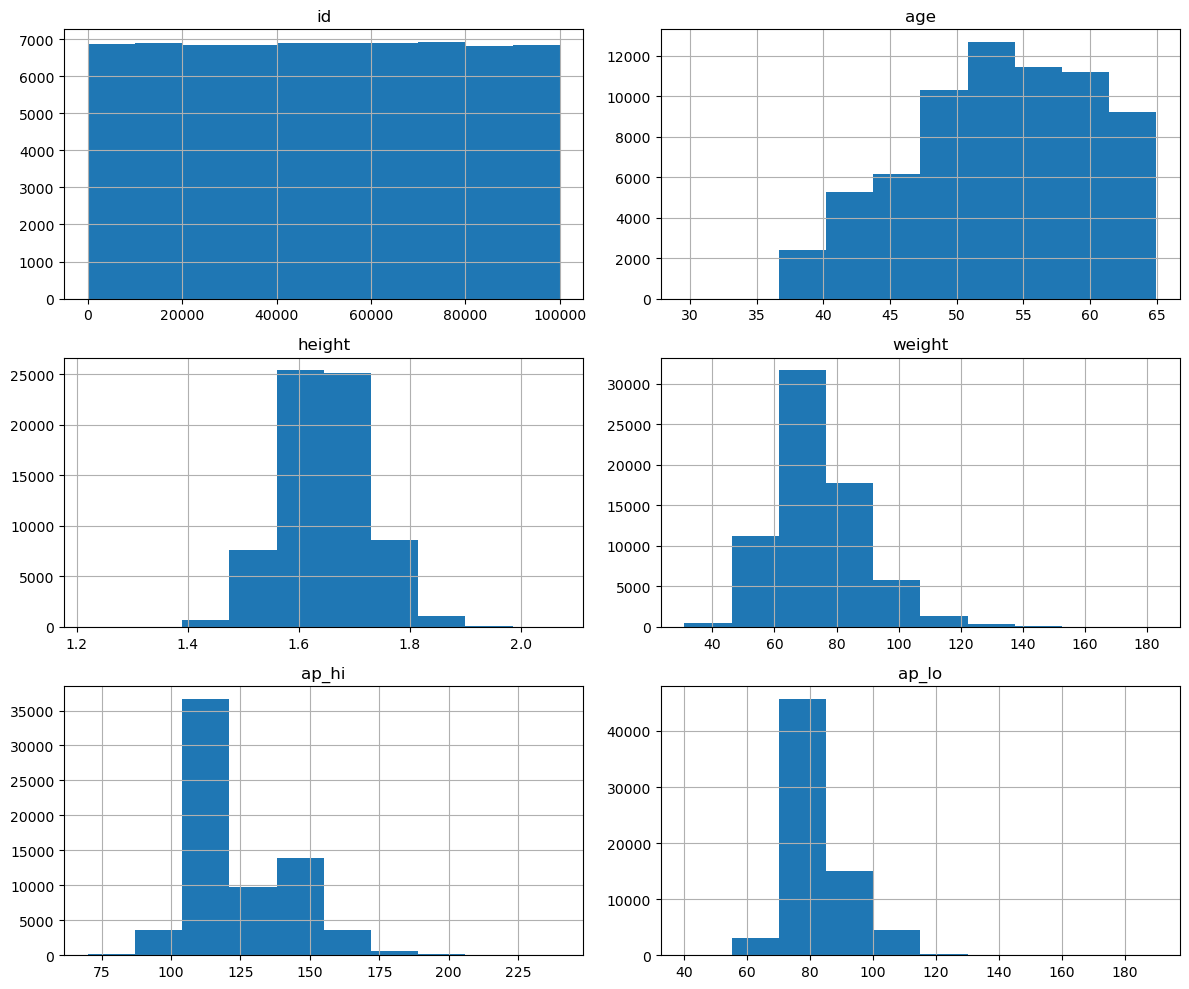

In [22]:
#histogram
df[num_cols].hist(figsize=(12,10))
plt.tight_layout()
plt.show()

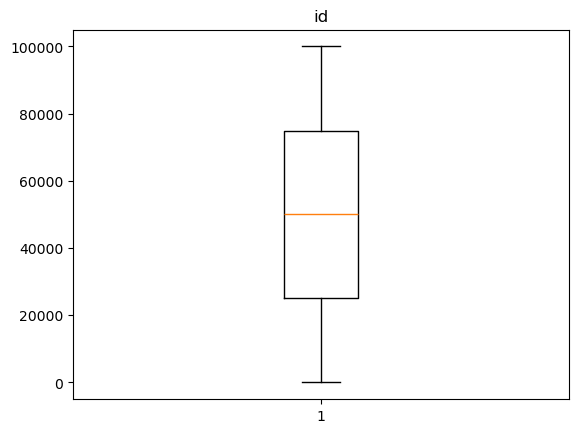

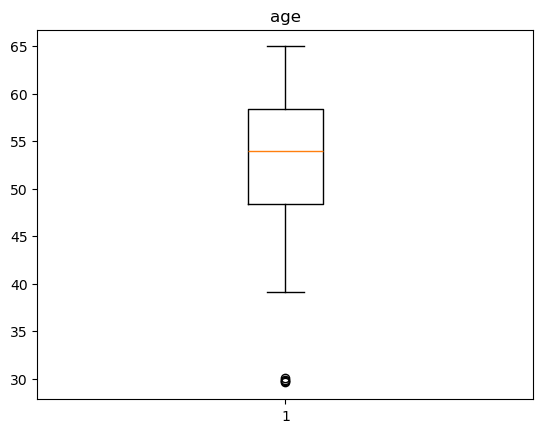

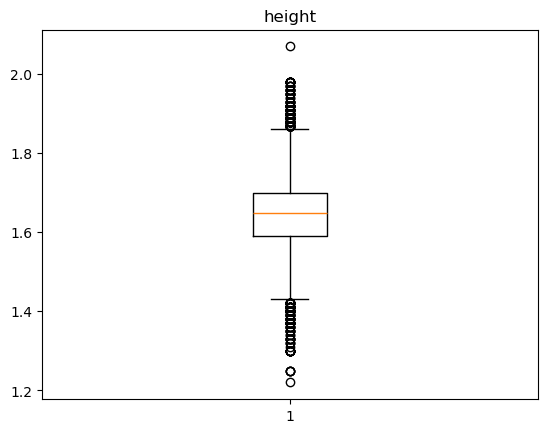

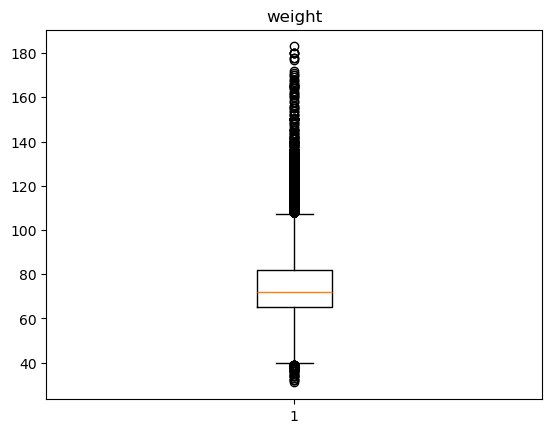

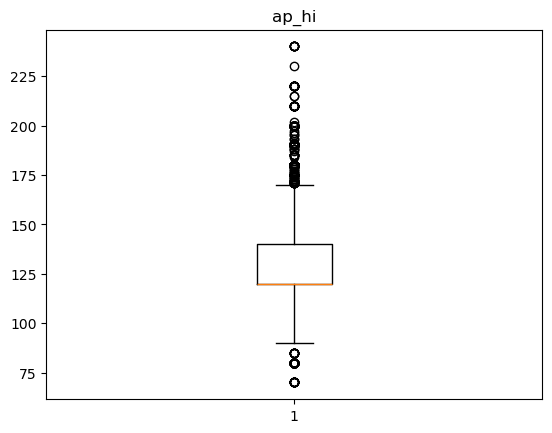

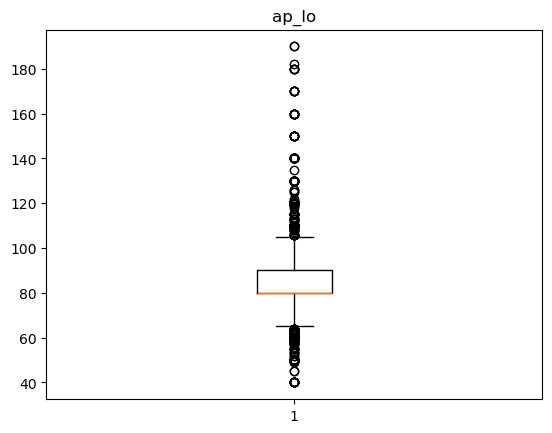

In [23]:
#boxplot
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

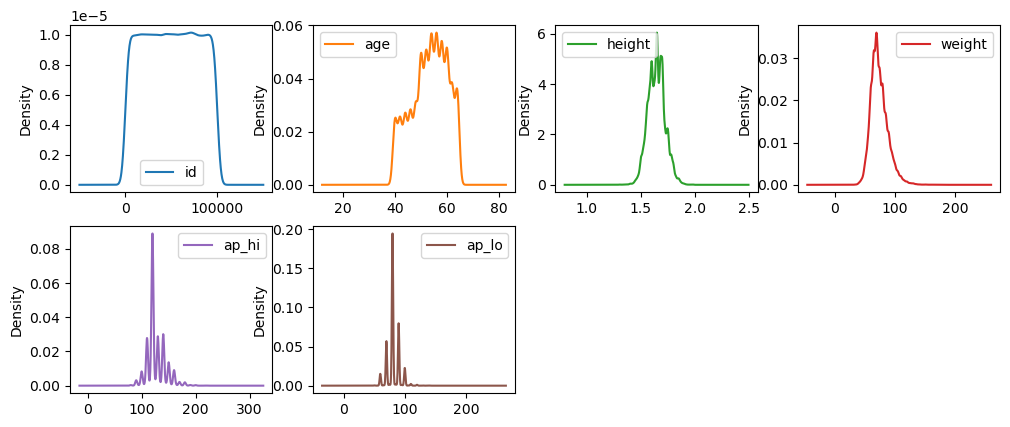

In [24]:
df[num_cols].plot(kind='density', subplots=True, layout=(4,4), figsize=(12,10), sharex=False)
plt.show()

In [25]:
df[num_cols].skew()

id       -0.001251
age      -0.305779
height    0.103715
weight    0.979625
ap_hi     0.907388
ap_lo     0.653720
dtype: float64

#### **3.1.2** Visualise the categorical features <font color = red>[5 marks]</font>

Visualise the distribution of categorical features to get a clear view of the data distribution across various categories. This will help in identifying potential imbalances or dominant categories.

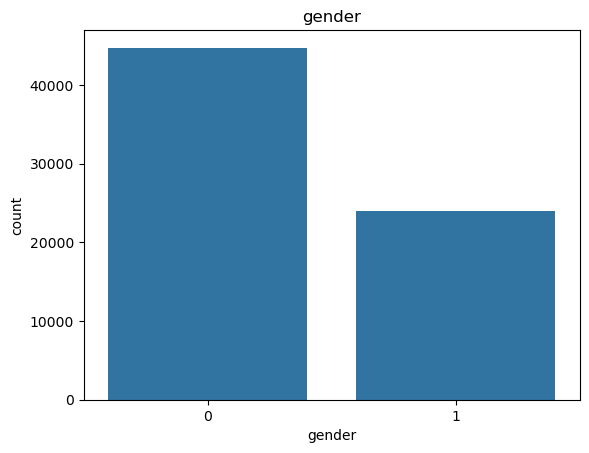

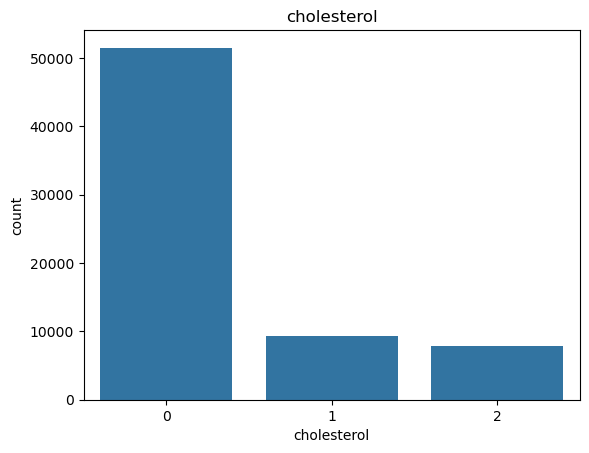

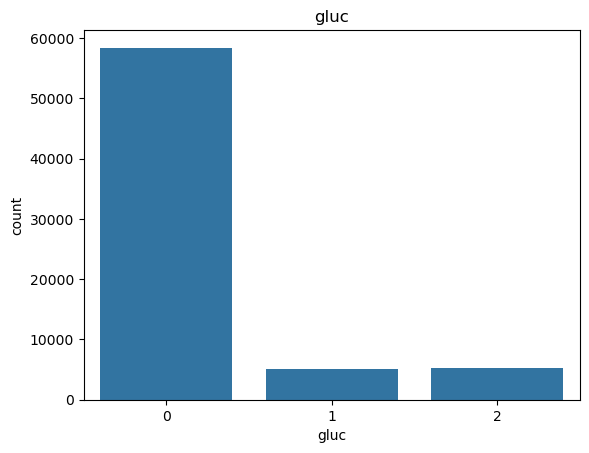

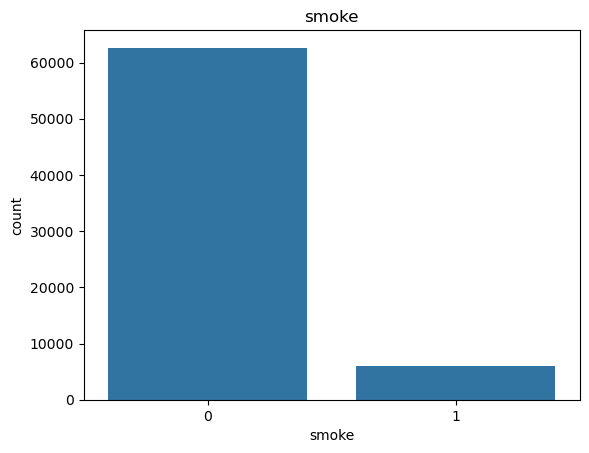

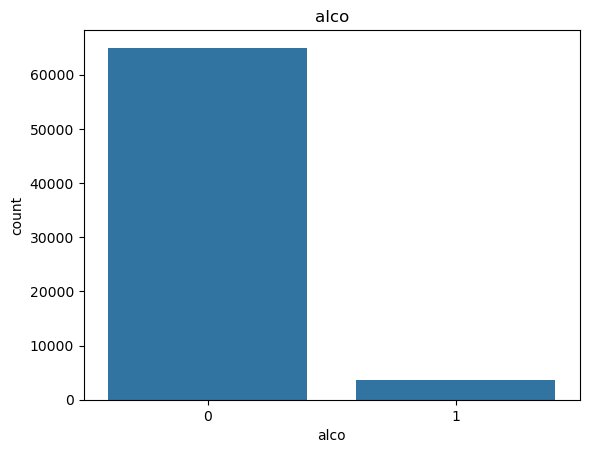

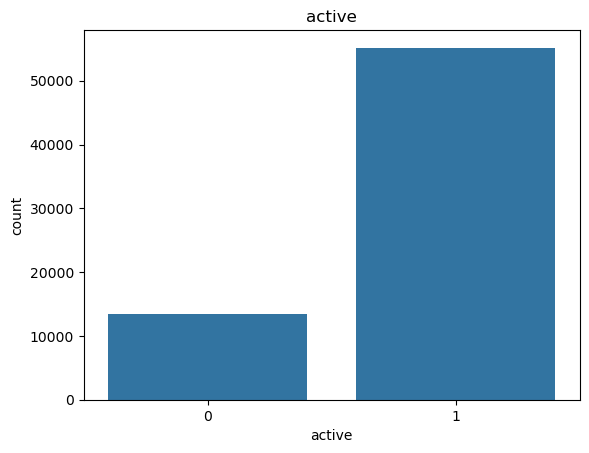

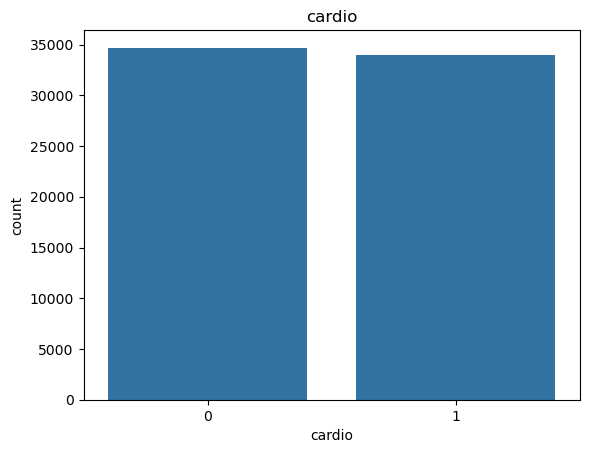

In [26]:
# Select and plot categorical columns
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

#### **3.1.3** Check class distribution of the target feature <font color = red>[2 marks]</font>

In [27]:
# Class distribution of positive and negative classes
df['cardio'].value_counts()

cardio
0    34688
1    33993
Name: count, dtype: int64

In [28]:
#Percentage Distribution
df['cardio'].value_counts(normalize=True) * 100

cardio
0    50.505962
1    49.494038
Name: proportion, dtype: float64

### **3.2 Perform correlation analysis** 

<font color = red>[5 marks]</font>

Investigate the relationships between numerical features to identify potential multicollinearity or dependencies. Visualise the correlation structure using an appropriate method to gain insights into feature relationships 

#### **3.2.1** Visualise the correlation among numerical features <font color="red">[5 Marks]</font>


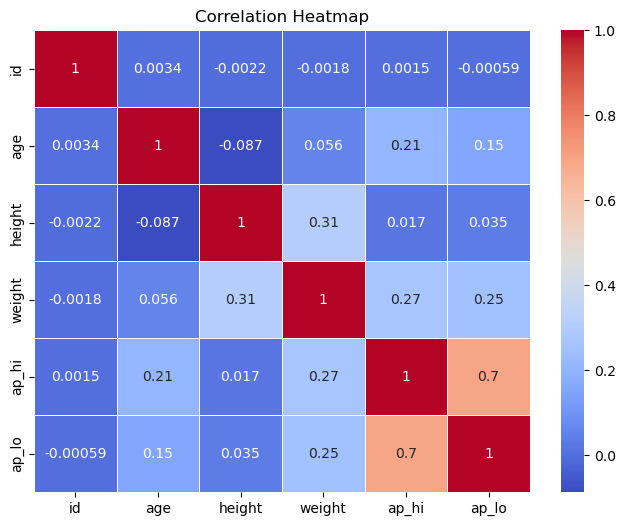

In [29]:
# Plot Heatmap of the correlation matrix
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.7)
plt.title("Correlation Heatmap")
plt.show()

### **3.3 Perform bivariate analysis** 

<font color = red>[10 marks]</font>

#### **3.3.1** Analyse categorical features <font color="red">[5 Marks]</font>

For each categorical feature (excluding the target), calculate the proportion of `cardio = 1` in each category of the feature. Use this to identify which categorical features show clear differences in heart disease likelihood and which are less informative.

In [30]:
# Write a function to analyse the target variable likelihood for categorical features
def analyze_categorical_impact(df, cat_cols, target='cardio'):
 
    results = {}
     # Ensure target is numeric
    df[target] = df[target].astype(int)
    for col in cat_cols:
        if col == target:
            continue
            
        print(f"\nFeature: {col}")
        
        # Calculate proportion of cardio = 1
        prop = df.groupby(col)[target].mean()
        
        print(prop)
        
        # Store results
        results[col] = prop
        
    return results


In [31]:
results = analyze_categorical_impact(df, cat_cols)


Feature: gender
gender
0    0.492321
1    0.499833
Name: cardio, dtype: float64

Feature: cholesterol
cholesterol
0    0.435601
1    0.596625
2    0.762757
Name: cardio, dtype: float64

Feature: gluc
gluc
0    0.475720
1    0.588641
2    0.618665
Name: cardio, dtype: float64

Feature: smoke
smoke
0    0.497469
1    0.468740
Name: cardio, dtype: float64

Feature: alco
alco
0    0.495892
1    0.478155
Name: cardio, dtype: float64

Feature: active
active
0    0.532706
1    0.485702
Name: cardio, dtype: float64


#### **3.3.2** Explore the relationships between numerical features and the target variable <font color = red>[5 marks]</font>

Understand the impact of numeric features on the target outcome using appropriate visualisation techniques to identify trends and potential interactions

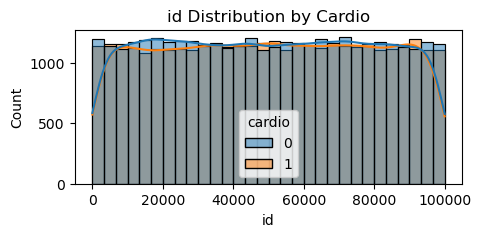

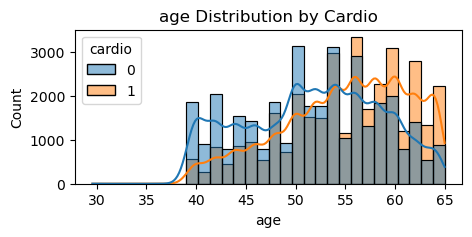

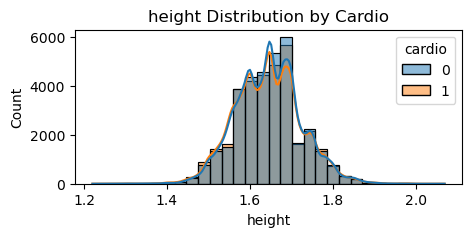

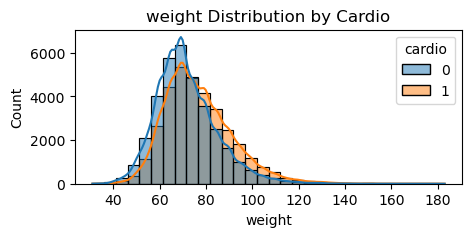

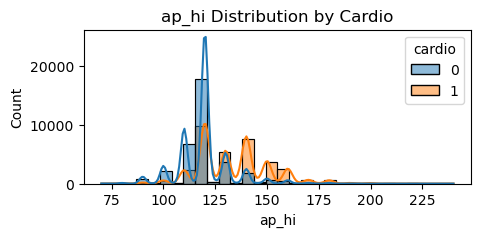

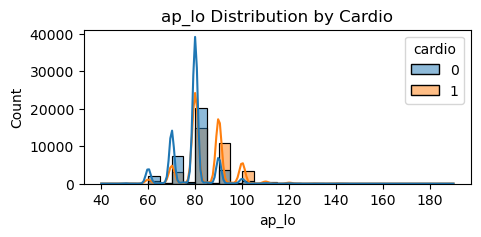

In [32]:
# Plot distribution for each numerical column with target variable

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.histplot(data=df, x=col, hue='cardio', kde=True, bins=30)
    plt.title(f"{col} Distribution by Cardio")
    plt.show()

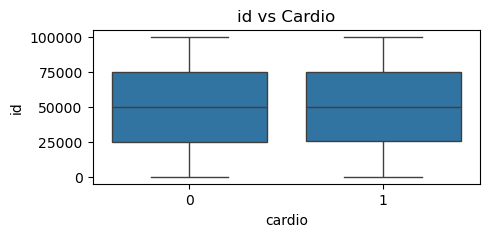

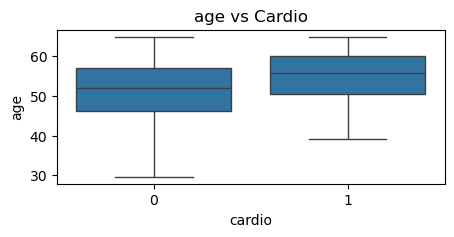

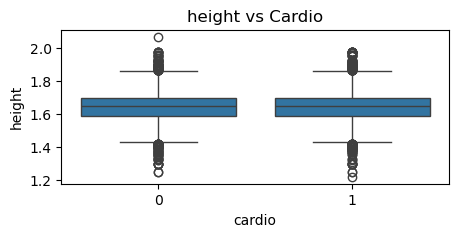

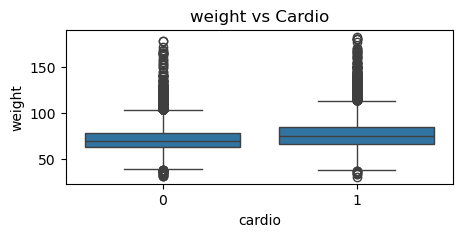

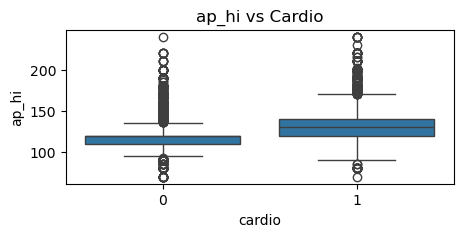

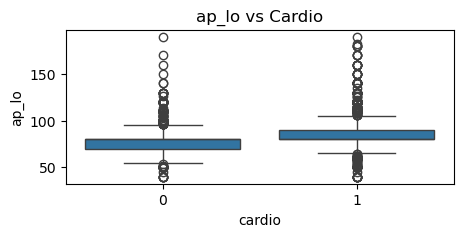

In [33]:
for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x='cardio', y=col, data=df)
    plt.title(f"{col} vs Cardio")
    plt.show()

## **4. Train-Test Split** 

<font color = red>[5 marks]</font>

### **4.1 Data Splitting** 

<font color = red>[5 Marks]</font>

#### **4.1.1** Define feature and target variables <font color = red>[2 Marks]</font>

In [34]:
# Put all the feature variables in X and target in y
X = df.drop('cardio', axis=1)
y = df['cardio']

In [35]:
df['cardio'] = df['cardio'].astype(int)

In [36]:
#dropping id
df.drop('id', axis=1, inplace=True)

In [37]:
print(X.shape)
print(y.shape)

(68681, 12)
(68681,)


#### **4.1.2** Split the data into train and test sets <font color="red">[3 Marks]</font>

Split the data in 0.7:0.3 sets. and reset the index for the sets. Check the shape of the test and test sets.


In [38]:
#  Split the data into 70% train data and 30% test data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 30% test
    random_state=42     # for reproducibility
)

In [39]:
# Reset index for all train and test sets
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

In [40]:
#checking
print(X_train.head())
print(y_train.head())

        id        age gender  height  weight  ap_hi  ap_lo cholesterol gluc  \
0  45518.0  64.652055      0    1.68    69.0  120.0   80.0           0    0   
1  96179.0  43.695890      0    1.52    54.0  100.0   70.0           0    0   
2   4501.0  50.443836      0    1.68    82.0  140.0   80.0           0    0   
3  31957.0  62.257534      0    1.70    84.0  140.0   90.0           0    0   
4  48537.0  62.060274      0    1.65    65.0  120.0   70.0           2    2   

  smoke alco active  
0     0    0      1  
1     0    0      1  
2     0    0      0  
3     0    0      1  
4     0    0      0  
0    1
1    0
2    1
3    1
4    0
Name: cardio, dtype: int64


## **5. Feature Engineering** 

<font color = red>[18 marks]</font>

### **5.1 Create a new feature** 

<font color = red>[6 marks]</font>

#### **5.1.1** Create a new feature `BMI` (Body Mass Index) <font color="red">[3 Marks]</font>

BMI is a standard health metric calculated using a person's height and weight. BMI is known to be a useful predictor for cardiovascular risk.

In [41]:
# Create a new feature 'BMI'
df['BMI'] = df['weight'] / (df['height'] ** 2)

In [42]:
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

In [43]:
df['age_BMI'] = df['age'] * df['BMI']
df['bp_ratio'] = df['ap_hi'] / (df['ap_lo'] + 1)

In [44]:
df['weight_height_ratio'] = df['weight'] / df['height']

**Note:** Feel free to engineer more features if you wish to.

#### **5.1.2** Perform correlation analysis  <font color="red">[3 Marks]</font>

After creating the new feature `BMI`, perform correlation analysis to check if it's correlated with any existing features. Perform suitable processing steps if high correlation is found.

In [45]:
# Plot check correlation 
corr = df.corr(numeric_only=True)
corr

,age,height,weight,ap_hi,ap_lo,cardio,BMI,pulse_pressure,age_BMI,bp_ratio,weight_height_ratio
age,1.000000,-0.086780,0.055570,0.208687,0.152666,0.239621,0.103641,0.165981,0.604367,0.098176,0.082215
height,-0.086780,1.000000,0.309609,0.017392,0.035193,-0.012409,-0.198327,-0.004022,-0.207029,-0.018107,0.059399
weight,0.055570,0.309609,1.000000,0.268988,0.249247,0.180327,0.865232,0.172251,0.713314,0.062437,0.966251
ap_hi,0.208687,0.017392,0.268988,1.000000,0.697773,0.425204,0.267628,0.822204,0.320976,0.490053,0.277729
ap_lo,0.152666,0.035193,0.249247,0.697773,1.000000,0.335154,0.238086,0.165987,0.266078,-0.260526,0.252275
cardio,0.239621,-0.012409,0.180327,0.425204,0.335154,1.000000,0.191233,0.319045,0.273859,0.173163,0.192326
BMI,0.103641,-0.198327,0.865232,0.267628,0.238086,0.191233,1.000000,0.179248,0.848808,0.073623,0.965083
pulse_pressure,0.165981,-0.004022,0.172251,0.822204,0.165987,0.319045,0.179248,1.000000,0.230447,0.881652,0.181879
age_BMI,0.604367,-0.207029,0.713314,0.320976,0.266078,0.273859,0.848808,0.230447,1.000000,0.112213,0.808134
bp_ratio,0.098176,-0.018107,0.062437,0.490053,-0.260526,0.173163,0.073623,0.881652,0.112213,1.000000,0.070341


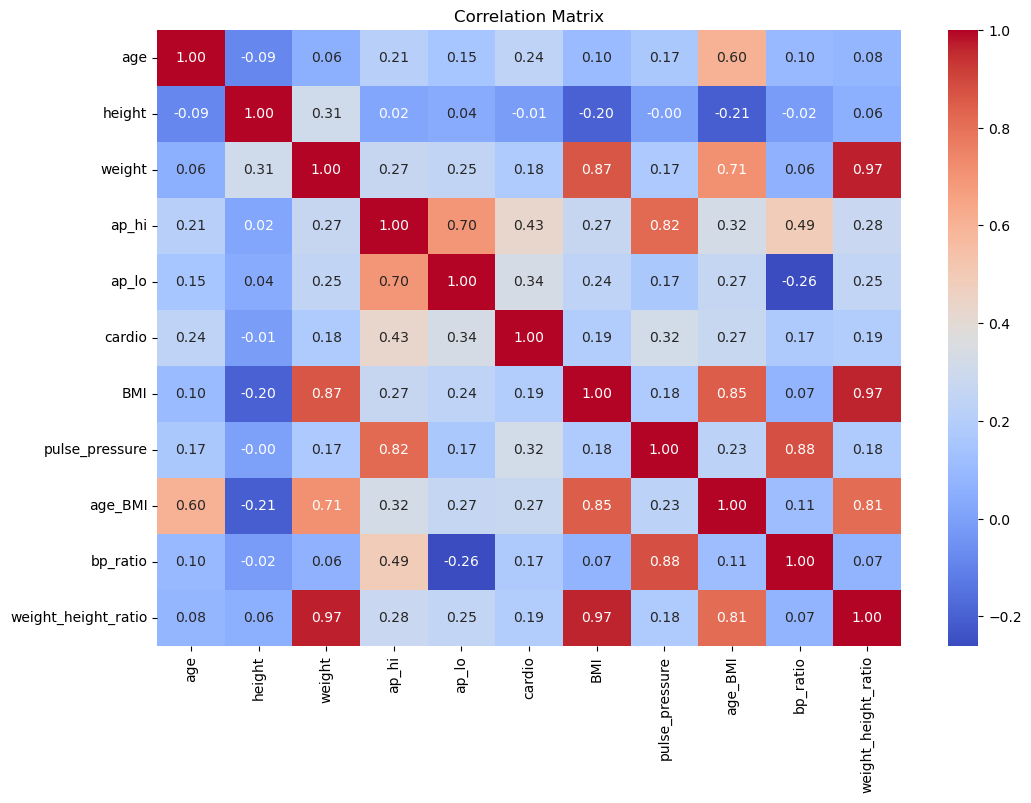

In [46]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [47]:
corr_target = corr['cardio'].sort_values(ascending=False)
print(corr_target)

cardio                 1.000000
ap_hi                  0.425204
ap_lo                  0.335154
pulse_pressure         0.319045
age_BMI                0.273859
age                    0.239621
weight_height_ratio    0.192326
BMI                    0.191233
weight                 0.180327
bp_ratio               0.173163
height                -0.012409
Name: cardio, dtype: float64


In [48]:
# Did you find any highly correlated features? What steps should you take
#Step 1: Identify high correlation pairs

high_corr = []

for i in corr.columns:
    for j in corr.columns:
        if i != j and abs(corr.loc[i,j]) > 0.8:
            high_corr.append((i,j,corr.loc[i,j]))

high_corr

[('weight', 'BMI', np.float64(0.8652315572183346)),
 ('weight', 'weight_height_ratio', np.float64(0.9662506077050538)),
 ('ap_hi', 'pulse_pressure', np.float64(0.822203641998808)),
 ('BMI', 'weight', np.float64(0.8652315572183346)),
 ('BMI', 'age_BMI', np.float64(0.8488075590827261)),
 ('BMI', 'weight_height_ratio', np.float64(0.9650833699796493)),
 ('pulse_pressure', 'ap_hi', np.float64(0.822203641998808)),
 ('pulse_pressure', 'bp_ratio', np.float64(0.8816524939391303)),
 ('age_BMI', 'BMI', np.float64(0.8488075590827261)),
 ('age_BMI', 'weight_height_ratio', np.float64(0.8081339629682609)),
 ('bp_ratio', 'pulse_pressure', np.float64(0.8816524939391303)),
 ('weight_height_ratio', 'weight', np.float64(0.9662506077050538)),
 ('weight_height_ratio', 'BMI', np.float64(0.9650833699796493)),
 ('weight_height_ratio', 'age_BMI', np.float64(0.8081339629682609))]

In [49]:
#Step 2:  Drop highly correlated redundant features
cols_to_drop = [
    'weight',
    'weight_height_ratio',
    'age_BMI',
    'bp_ratio'
]

df = df.drop(columns=cols_to_drop)

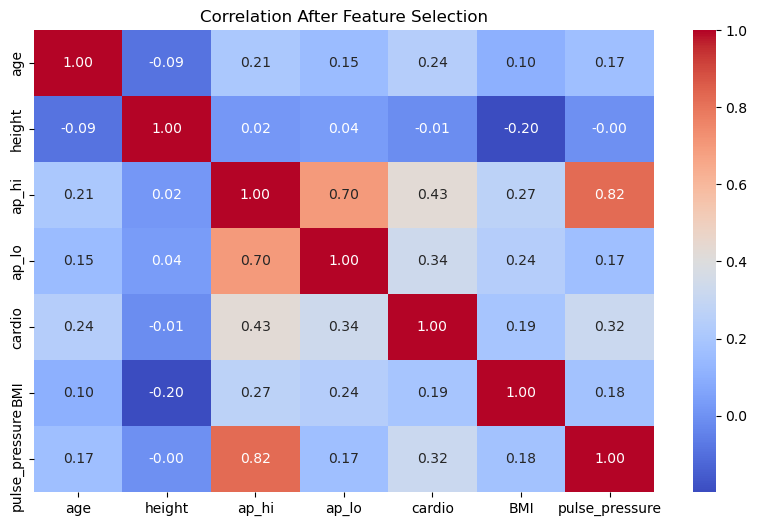

In [50]:
#recheck correlatio
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation After Feature Selection")
plt.show()

### **5.2 Combine Values in Categorical Columns** 

<font color="red">[4 Marks]</font>

#### **5.2.1** Combine Low-Frequency Categories <font color="red">[4 Marks]</font>

During the EDA process, categorical columns with multiple unique levels may be identified. To enhance model performance, it is recommended to refine these categorical features by grouping values that have low frequency or provide limited predictive information.

Combine categories that occur infrequently or exhibit similar behavior to reduce sparsity and improve model generalisation.

In [51]:
 # Combine categories that have low frequency or provide limited predictive information such as gluc and cholesterol
# Combine cholesterol categories
df['cholesterol_bin'] = df['cholesterol'].apply(lambda x: 0 if x == 1 else 1)

# Combine glucose categories
df['gluc_bin'] = df['gluc'].apply(lambda x: 0 if x == 1 else 1)


In [52]:
#Dropig Original Columns
df = df.drop(columns=['cholesterol', 'gluc'])

In [53]:
print(df['cholesterol_bin'].value_counts())
print(df['gluc_bin'].value_counts())

cholesterol_bin
1    59377
0     9304
Name: count, dtype: int64
gluc_bin
1    63610
0     5071
Name: count, dtype: int64


In [54]:
df.columns

Index(['age', 'gender', 'height', 'ap_hi', 'ap_lo', 'smoke', 'alco', 'active',
       'cardio', 'BMI', 'pulse_pressure', 'cholesterol_bin', 'gluc_bin'],
      dtype='object')

### **5.3 Dummy variable creation** 

<font color = red>[5 marks]</font>

#### **5.3.1** Create dummy variables for categorical columns <font color="red">[5 Mark]</font>

In [55]:
# Identify the columns for creating dummy variables
X = df.drop('cardio', axis=1)
y = df['cardio']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)



In [56]:
# Create dummy variables for independent columns on training data
X_train = pd.get_dummies(X_train, drop_first=True)

In [57]:
# Create dummy variables for independent columns on test data
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns to avoid mismatch
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [58]:
X_train.columns

Index(['age', 'height', 'ap_hi', 'ap_lo', 'BMI', 'pulse_pressure',
       'cholesterol_bin', 'gluc_bin', 'gender_1', 'smoke_1', 'alco_1',
       'active_1'],
      dtype='object')

### **5.4 Feature scaling** 

<font color = red>[3 marks]</font>

#### **5.4.1** Scale numerical features <font color = red>[3 marks]</font>

Choose a scaling method appropriate for the data and the chosen model. Apply the same scaling to both training and test data.

In [59]:
# Scale the numeric features present in the training data
from sklearn.preprocessing import StandardScaler
# numeric columns
num_cols = ['age', 'height', 'ap_hi', 'ap_lo', 'BMI', 'pulse_pressure']

# initialize scaler
scaler = StandardScaler()

# fit ONLY on training data
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Scale the numerical features present in the test data
X_test[num_cols] = scaler.transform(X_test[num_cols])


## **6. Model Building** 

<font color = red>[38 marks]</font>

In this task, you will build the two machine learning models: Support Vector Classifier (SVC) and a Decision Tree classifier. We will follow the same structured workflow for the models:

* *Model Building and Initial Evaluation*: <br> Fit the model and evaluate its performance on the training data using the default cutoff
* *Find the Optimal Cutoff*: <br> Determine the best probability threshold using sensitivity-specificity and precision–recall trade-offs
* *Model Prediction & Evaluation using chosen cutoff*: <br> Generate predictions using the chosen cutoff and evaluate performance on the training data
* *Hyperparameter Tuning (Grid Search)*: <br> Optimise performance using grid search for hyperparameter tuning
* *Final Model Training & Evaluation using chosen cutoff*: <br> Train the final model using the best hyperparameters and evaluate performance on the training data

### **6.1 SVM Classifier** 

<font color = red>[18 marks]</font>

#### **6.1.1** Define a Linear SVM classifier and fit it on the train set <font color = red>[2 mark]</font>

Go through the [SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) and define a model with linear kernel that will also return the probabilities estimates of the predictions.

In [60]:
# Define and fit linear SVM
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

base_svm = LinearSVC(C=1.0, random_state=42)

svm_model = CalibratedClassifierCV(base_svm)
svm_model.fit(X_train, y_train)

CalibratedClassifierCV(estimator=LinearSVC(random_state=42))

#### **6.1.2** Get the probability estimates on test set and predict class using a threshold <font color = red>[3 mark]</font>

We defined the model to also return the probabilities after training. Use the `SVC.predict_proba()`[(documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC.predict_proba) function to fetch the probabilities on test set. For each sample, it returns the probabilities of each class in a sorted order (according to `SVC.classes_`)

After getting the probability values, assign class labels using the default threshold of 0.5 and check the distribution of assigned labels.

In [61]:
# Use predict_proba() to get the probability of positive class for all data points

#Extract positive class probability
y_prob = svm_model.predict_proba(X_test)[:, 1]

y_prob_train = svm_model.predict_proba(X_train)[:, 1]


In [62]:
# Make class predictions based on default cutoff value of 0.5 on testing data
y_pred = (svm_model.predict_proba(X_test)[:, 1] >= 0.5).astype(int)


# convert to class labels
y_pred_prob = (y_prob >= 0.5).astype(int)

In [63]:
# check the counts of assigned labels
pd.Series(y_pred).value_counts().rename({
    0: 'No Disease',
    1: 'Disease'
})

No Disease    11401
Disease        9204
Name: count, dtype: int64

In [64]:
# % distribution
pd.Series(y_pred).value_counts(normalize=True) * 100

0    55.33123
1    44.66877
Name: proportion, dtype: float64

#### **6.1.3** Predict the class labels using the `predict()` function <font color = red>[2 mark]</font>

Now, directly use the `predict()` function to predict the class labels and check the distribution of assigned labels using this method.

In [65]:
# Make class predictions using predict()
y_pred_direct = svm_model.predict(X_test)

In [66]:
# check the counts of assigned labels
pd.Series(y_pred_direct).value_counts()

0    11401
1     9204
Name: count, dtype: int64

Did you find any difference in the distribution of classes in the predictions using these two methods? Why do you think that is?

Try going through the documentation of `predict_proba()` linked above.

#### **6.1.4** Calculate performance metrics for both the above methods <font color = red>[3 mark]</font>

Calculate the performance metrics for both `predict_proba()` and `predict()` estimates. Compare the results and choose one to continue ahead.

No, I did not find any difference in the distribution of predicted classes using the two methods. This is because the predict() function internally uses a decision threshold equivalent to 0.5 probability. Since I also used a threshold of 0.5 on the predicted probabilities, both methods produced identical class labels. Differences would arise if a different threshold (e.g., 0.3 or 0.7) was used or if the model was not properly calibrated.

In [67]:
# check the performance for above two methods
print("=== Using predict() ===")
print("Accuracy:", accuracy_score(y_test, y_pred_direct))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_direct))
print("Classification Report:\n", classification_report(y_test, y_pred_direct))

print("\n=== Using predict_proba() (0.5 threshold) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_prob))
print("Classification Report:\n", classification_report(y_test, y_pred_prob))

=== Using predict() ===
Accuracy: 0.721572433875273
Confusion Matrix:
 [[7999 2335]
 [3402 6869]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.77      0.74     10334
           1       0.75      0.67      0.71     10271

    accuracy                           0.72     20605
   macro avg       0.72      0.72      0.72     20605
weighted avg       0.72      0.72      0.72     20605


=== Using predict_proba() (0.5 threshold) ===
Accuracy: 0.721572433875273
Confusion Matrix:
 [[7999 2335]
 [3402 6869]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.77      0.74     10334
           1       0.75      0.67      0.71     10271

    accuracy                           0.72     20605
   macro avg       0.72      0.72      0.72     20605
weighted avg       0.72      0.72      0.72     20605



#### **6.1.5** Plot the ROC curve <font color="red">[2 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

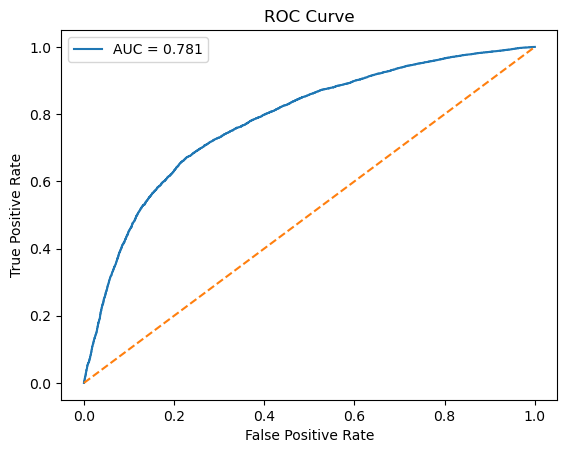

In [68]:
# Plot the ROC curve
 # Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [69]:
print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.7812054688184382


#### **6.1.6** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[3 Marks]</font>

In [70]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs

# Create function to compute metrics
def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn)  # recall
    specificity = tn / (tn + fp)
    
    return accuracy, sensitivity, specificity

In [71]:
thresholds = np.arange(0, 1.1, 0.1)

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    acc, sens, spec = compute_metrics(y_test, y_pred)
    
    results.append([t, acc, sens, spec])

df_metrics = pd.DataFrame(results, columns=[
    'threshold', 'accuracy', 'sensitivity', 'specificity'
])

df_metrics

,threshold,accuracy,sensitivity,specificity
0,0.0,0.498471,1.000000,0.000000
1,0.1,0.517690,0.994742,0.043546
2,0.2,0.573696,0.970889,0.178924
3,0.3,0.642708,0.906144,0.380879
4,0.4,0.696870,0.803817,0.590575
5,0.5,0.721572,0.668776,0.774047
6,0.6,0.699102,0.527991,0.869170
7,0.7,0.655666,0.388570,0.921134
8,0.8,0.597816,0.235810,0.957616
9,0.9,0.538025,0.089086,0.984227


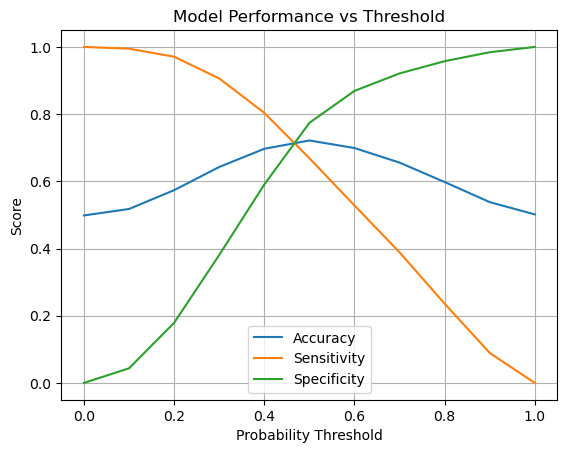

In [72]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs stored in DF
plt.figure()

plt.plot(df_metrics['threshold'], df_metrics['accuracy'], label='Accuracy')
plt.plot(df_metrics['threshold'], df_metrics['sensitivity'], label='Sensitivity')
plt.plot(df_metrics['threshold'], df_metrics['specificity'], label='Specificity')

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Model Performance vs Threshold")

plt.legend()
plt.grid()

plt.show()

To minimise the risk of missing high cardiovascular risk individuals, we should prioritise our model's ability to correctly identify those with cardiovascular disease.

#### **6.1.7** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [73]:
# Make final prediction based on the optimal cutoff
optimal_threshold = 0.4  

# Train probabilities
y_prob_train = svm_model.predict_proba(X_train)[:, 1]

# Test probabilities
y_prob_test = svm_model.predict_proba(X_test)[:, 1]

# Train predictions
y_pred_train = (y_prob_train >= optimal_threshold).astype(int)

# Test predictions
y_pred_test = (y_prob_test >= optimal_threshold).astype(int)

print("=== TRAIN PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_train))
print("Classification Report:\n", classification_report(y_train, y_pred_train))

print("\n=== TEST PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print("Classification Report:\n", classification_report(y_test, y_pred_test))

=== TRAIN PERFORMANCE ===
Accuracy: 0.6987478159580663
Confusion Matrix:
 [[14458  9896]
 [ 4587 19135]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.59      0.67     24354
           1       0.66      0.81      0.73     23722

    accuracy                           0.70     48076
   macro avg       0.71      0.70      0.70     48076
weighted avg       0.71      0.70      0.70     48076


=== TEST PERFORMANCE ===
Accuracy: 0.6968696918223732
Confusion Matrix:
 [[6103 4231]
 [2015 8256]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.59      0.66     10334
           1       0.66      0.80      0.73     10271

    accuracy                           0.70     20605
   macro avg       0.71      0.70      0.69     20605
weighted avg       0.71      0.70      0.69     20605



In [74]:
# Evaluate the model performance 

print("=== TEST PERFORMANCE ===")

print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))

# ROC-AUC (important)
y_prob_test = svm_model.predict_proba(X_test)[:, 1]
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_test))

=== TEST PERFORMANCE ===
Accuracy: 0.6968696918223732

Confusion Matrix:
 [[6103 4231]
 [2015 8256]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.59      0.66     10334
           1       0.66      0.80      0.73     10271

    accuracy                           0.70     20605
   macro avg       0.71      0.70      0.69     20605
weighted avg       0.71      0.70      0.69     20605


ROC-AUC Score: 0.7812054688184382


In [75]:
# Check performance on training data

# Get probabilities for training data
y_prob_train = svm_model.predict_proba(X_train)[:, 1]

# Convert to class labels using optimal threshold
y_pred_train = (y_prob_train >= optimal_threshold).astype(int)


print("=== TRAIN PERFORMANCE ===")

print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))

# ROC-AUC
print("\nROC-AUC Score:", roc_auc_score(y_train, y_prob_train))

=== TRAIN PERFORMANCE ===
Accuracy: 0.6987478159580663

Confusion Matrix:
 [[14458  9896]
 [ 4587 19135]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.59      0.67     24354
           1       0.66      0.81      0.73     23722

    accuracy                           0.70     48076
   macro avg       0.71      0.70      0.70     48076
weighted avg       0.71      0.70      0.70     48076


ROC-AUC Score: 0.7824153904361943


#### **6.1.8** Plot precision-recall curve <font color="red">[1 Mark]</font>

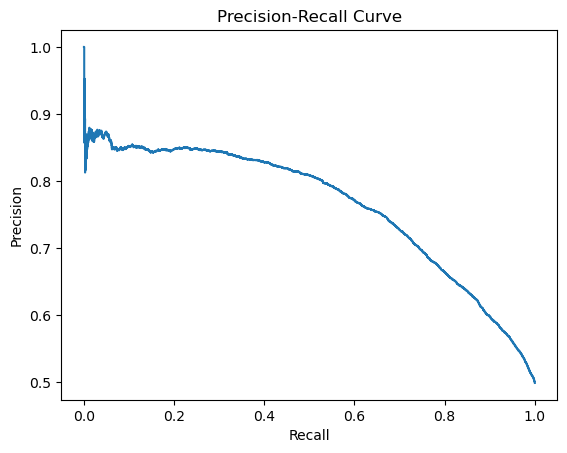

In [76]:
# Compute precision–recall values and plot for various thresholds

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

Since we want to prioritise recall/sensitivity over precision to minimise the risk of missing high-risk individuals, we can choose an agreeable cutoff value.

### **6.2 Decision Tree Classifier** 

<font color = red>[12 marks]</font>

#### **6.2.1** Define a Decision Tree classifier and fit it on the train set <font color = red>[1 mark]</font>

In [77]:
# Define and fit
dt_model = DecisionTreeClassifier(
    max_depth=5,          # control overfitting
    min_samples_split=10, # minimum samples to split
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

#### **6.2.2** Get feature importance scores <font color = red>[2 Marks]</font>

In [78]:
# Get feature importance scores from the trained model


feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_model.feature_importances_
})

feature_importance

#Sort by Importance
feature_importance = feature_importance.sort_values(by='importance', ascending=False)

feature_importance

,feature,importance
2,ap_hi,0.826665
0,age,0.136228
4,BMI,0.021737
3,ap_lo,0.005150
5,pulse_pressure,0.004163
6,cholesterol_bin,0.003038
9,smoke_1,0.001767
1,height,0.001252
7,gluc_bin,0.000000
8,gender_1,0.000000


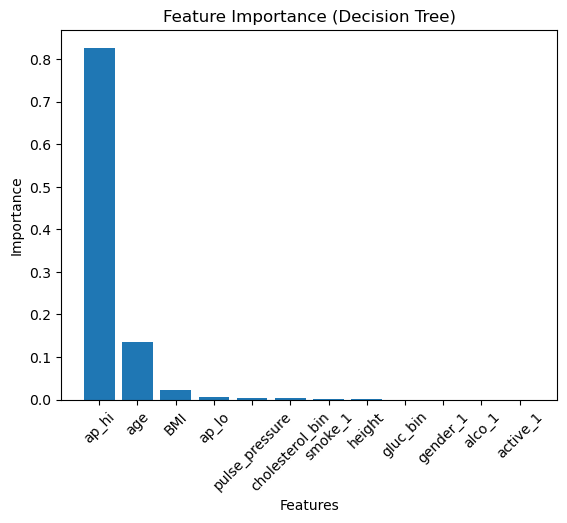

In [79]:
#ploting

plt.figure()

plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance (Decision Tree)")

plt.show()

#### **6.2.3** Predict the class probabilities on the test set <font color="red">[1 Mark]</font>

Use `predict_proba()` to get the probability estimates

In [80]:
# Predict the class probabilities
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]


####  **6.2.4** Make prediction based on default cutoff value of 0.5 on testing data <font color = "red">[1 Mark]</font>

In [81]:
# Make prediction based on default cutoff value of 0.5

y_pred_dt = (dt_model.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

pd.Series(y_pred_dt).value_counts()

0    10575
1    10030
Name: count, dtype: int64

####  **6.2.5** Evaluate the performance of the model <font color = "red">[1 Mark]</font>

In [82]:
# Evaluate the performance of the model on training data

y_prob_train_dt = dt_model.predict_proba(X_train)[:, 1]

y_pred_train_dt = (y_prob_train_dt >= 0.5).astype(int)

print("=== DECISION TREE - TRAIN PERFORMANCE ===")

print("Accuracy:", accuracy_score(y_train, y_pred_train_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_train_dt))
print("\nClassification Report:\n", classification_report(y_train, y_pred_train_dt))

# ROC-AUC
print("\nROC-AUC Score:", roc_auc_score(y_train, y_prob_train_dt))

=== DECISION TREE - TRAIN PERFORMANCE ===
Accuracy: 0.7240619019885182

Confusion Matrix:
 [[18003  6351]
 [ 6915 16807]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.74      0.73     24354
           1       0.73      0.71      0.72     23722

    accuracy                           0.72     48076
   macro avg       0.72      0.72      0.72     48076
weighted avg       0.72      0.72      0.72     48076


ROC-AUC Score: 0.7877420577397031


#### **6.2.6** Plot the ROC curve <font color="red">[1 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

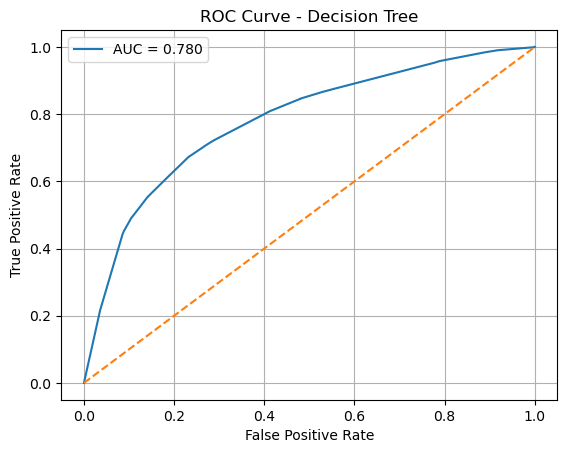

In [83]:
# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)
auc_score = roc_auc_score(y_test, y_prob_dt)

plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")

plt.legend()
plt.grid()

plt.show()

**Sensitivity and Specificity tradeoff**

Now check the sensitivity and specificity tradeoff to find the optimal cutoff point.

#### **6.2.7** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[2 Marks]</font>

In [84]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs

def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn)   # recall
    specificity = tn / (tn + fp)
    
    return accuracy, sensitivity, specificity

In [85]:
thresholds = np.arange(0, 1.1, 0.1)

results = []

for t in thresholds:
    y_pred = (y_prob_dt >= t).astype(int)
    
    acc, sens, spec = compute_metrics(y_test, y_pred)
    
    results.append([t, acc, sens, spec])

df_metrics_dt = pd.DataFrame(results, columns=[
    'threshold', 'accuracy', 'sensitivity', 'specificity'
])

df_metrics_dt

,threshold,accuracy,sensitivity,specificity
0,0.0,0.498471,1.000000,0.000000
1,0.1,0.534725,0.990166,0.082059
2,0.2,0.583839,0.957258,0.212696
3,0.3,0.682650,0.845974,0.520321
4,0.4,0.698762,0.804595,0.593575
5,0.5,0.718563,0.705968,0.731082
6,0.6,0.705654,0.548924,0.861428
7,0.7,0.682262,0.451563,0.911554
8,0.8,0.679544,0.443482,0.914167
9,0.9,0.501529,0.000000,1.000000


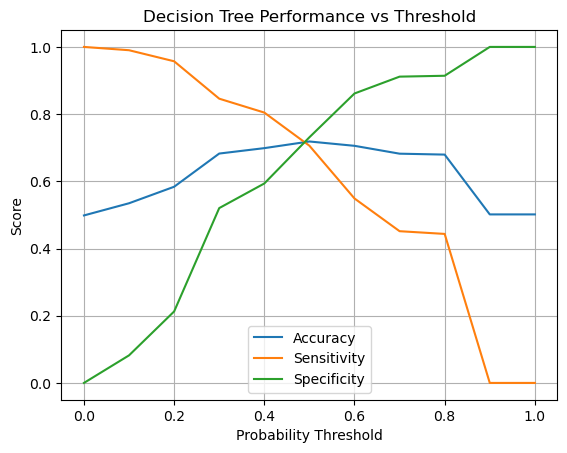

In [86]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs
plt.figure()

plt.plot(df_metrics_dt['threshold'], df_metrics_dt['accuracy'], label='Accuracy')
plt.plot(df_metrics_dt['threshold'], df_metrics_dt['sensitivity'], label='Sensitivity')
plt.plot(df_metrics_dt['threshold'], df_metrics_dt['specificity'], label='Specificity')

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Decision Tree Performance vs Threshold")

plt.legend()
plt.grid()

plt.show()


#### **6.2.8** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [87]:
# Make final prediction based on the optimal cutoff
y_pred_final = (y_prob_dt >= optimal_threshold).astype(int)

pd.Series(y_pred_final).value_counts()

1    12464
0     8141
Name: count, dtype: int64

In [88]:
print("Final Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))

Final Model Performance:
Accuracy: 0.6987624363018685

Confusion Matrix:
 [[6134 4200]
 [2007 8264]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.59      0.66     10334
           1       0.66      0.80      0.73     10271

    accuracy                           0.70     20605
   macro avg       0.71      0.70      0.70     20605
weighted avg       0.71      0.70      0.70     20605



In [89]:
# Evaluate the model performance for test and train
# Train probabilities
y_prob_train = dt_model.predict_proba(X_train)[:, 1]

# Test probabilities
y_prob_test = dt_model.predict_proba(X_test)[:, 1]

optimal_threshold = 0.4   # use your chosen value

# Train predictions
y_pred_train = (y_prob_train >= optimal_threshold).astype(int)

# Test predictions
y_pred_test = (y_prob_test >= optimal_threshold).astype(int)


print("=== TRAIN PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_train))
print("Classification Report:\n", classification_report(y_train, y_pred_train))
print("ROC-AUC:", roc_auc_score(y_train, y_prob_train))

print("\n=== TEST PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print("Classification Report:\n", classification_report(y_test, y_pred_test))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_test))

=== TRAIN PERFORMANCE ===
Accuracy: 0.7002870455112739
Confusion Matrix:
 [[14517  9837]
 [ 4572 19150]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.60      0.67     24354
           1       0.66      0.81      0.73     23722

    accuracy                           0.70     48076
   macro avg       0.71      0.70      0.70     48076
weighted avg       0.71      0.70      0.70     48076

ROC-AUC: 0.7877420577397031

=== TEST PERFORMANCE ===
Accuracy: 0.6987624363018685
Confusion Matrix:
 [[6134 4200]
 [2007 8264]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.59      0.66     10334
           1       0.66      0.80      0.73     10271

    accuracy                           0.70     20605
   macro avg       0.71      0.70      0.70     20605
weighted avg       0.71      0.70      0.70     20605

ROC-AUC: 0.7804022976561051


**Precision and Recall tradeoff**

Check optimal cutoff value by plotting precision-recall curve, and adjust the cutoff based on precision and recall tradeoff if required.

#### **6.2.9** Plot precision-recall curve <font color="red">[1 Mark]</font>

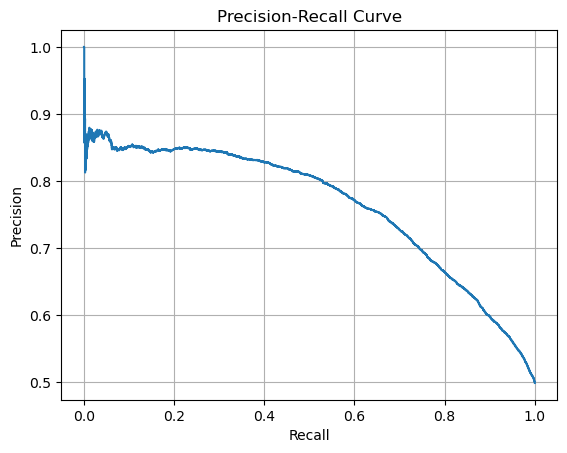

In [90]:
# Compute and plot precision–recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid()

plt.show()

#### **6.2.10** Build another model of your choice.

Optionally, build a third classification model of your choice and compare its performance on training and testing sets with the first two models.

### **6.3 Hyperparameter Tuning** 

<font color = red>[8 Marks]</font>

Enhance the performance of the decision tree model by systematically exploring and selecting optimal hyperparameter values using Grid Search.

#### **6.3.1** Use grid search to find the best hyperparameter values <font color = red>[4 Marks]</font>

Perform hyperparameter tuning to see if the performance of the decision tree model can be improved. Tune for **at least 4 decision tree hyperparameters**.

In [91]:
# Use grid search to find best hyperparameters for decision tree model
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt = DecisionTreeClassifier(random_state=42)


# Define the parameter grid for the decision tree
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)




GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [92]:
# Print the best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


#### **6.3.2** Build a decision tree model based on hyperparameter tuning results <font color = red>[2 Marks]</font>


In [93]:
# Use the best DT from grid search
best_dt_model = grid_search.best_estimator_

#### **6.3.3** Using the tuned model, make predictions and evaluate <font color="red">[2 Mark]</font>

Use the tuned model to directly predict the labels and evaluate the performance on both training and testing sets to check overfitting / underfitting.

In [94]:
# Evaluate the model performance on training set 
y_pred_train_best = best_dt_model.predict(X_train)
print("=== TUNED DT - TRAIN PERFORMANCE ===")

print("Accuracy:", accuracy_score(y_train, y_pred_train_best))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_train_best))
print("\nClassification Report:\n", classification_report(y_train, y_pred_train_best))

# ROC-AUC
y_prob_train_best = best_dt_model.predict_proba(X_train)[:, 1]
print("\nROC-AUC:", roc_auc_score(y_train, y_prob_train_best))

=== TUNED DT - TRAIN PERFORMANCE ===
Accuracy: 0.7203594309010733

Confusion Matrix:
 [[18355  5999]
 [ 7445 16277]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.75      0.73     24354
           1       0.73      0.69      0.71     23722

    accuracy                           0.72     48076
   macro avg       0.72      0.72      0.72     48076
weighted avg       0.72      0.72      0.72     48076


ROC-AUC: 0.7778606839204082


In [95]:
# Evaluate the model performance on test set 
y_pred_test_best = best_dt_model.predict(X_test)

print("\n=== TUNED DT - TEST PERFORMANCE ===")

print("Accuracy:", accuracy_score(y_test, y_pred_test_best))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test_best))

y_prob_test_best = best_dt_model.predict_proba(X_test)[:, 1]
print("\nROC-AUC:", roc_auc_score(y_test, y_prob_test_best))


=== TUNED DT - TEST PERFORMANCE ===
Accuracy: 0.7196311574860471

Confusion Matrix:
 [[7770 2564]
 [3213 7058]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.75      0.73     10334
           1       0.73      0.69      0.71     10271

    accuracy                           0.72     20605
   macro avg       0.72      0.72      0.72     20605
weighted avg       0.72      0.72      0.72     20605


ROC-AUC: 0.7732489593935827


#### **6.3.4** Optionally, use grid search to find the best hyperparameter values for SVM

Try to fine-tune SVM hyperparameters like kernels, `C` and `gamma`.

You can also check the performance of SVM with `RBF` kernel

Tune your third candidate model, if taken

## **7. Final Model Evaluation and Selection** 

<font color = red>[2 Marks]</font>

Use you final models to make predictions on the test data. Evaluate the models, create model cards, and finally write your conclusive findings, results, and insights from the steps performed.

Include these in your report as well.

### **7.1 Evaluate the final models** 

<font color = red>[2 Marks]</font>

Make predictions using the tuned models and selected features to check the training and testing performances and create model cards for both.

#### **7.1.1** Make final predictions and evaluate <font color="red">[2 Marks]</font>

Evaluate the performance of your final candidates

In [96]:
# Make predictions on test and train sets using all candidate models
# use the chosen optimal cutoff
# Decision Tree
y_prob_train_dt = best_dt_model.predict_proba(X_train)[:, 1]
y_prob_test_dt  = best_dt_model.predict_proba(X_test)[:, 1]

# SVM
y_prob_train_svm = svm_model.predict_proba(X_train)[:, 1]
y_prob_test_svm  = svm_model.predict_proba(X_test)[:, 1]

# Decision Tree predictions
y_pred_train_dt = (y_prob_train_dt >= optimal_threshold).astype(int)
y_pred_test_dt  = (y_prob_test_dt  >= optimal_threshold).astype(int)

# SVM predictions
y_pred_train_svm = (y_prob_train_svm >= optimal_threshold).astype(int)
y_pred_test_svm  = (y_prob_test_svm  >= optimal_threshold).astype(int)

In [97]:
import pandas as pd

print("DT Test Distribution:\n", pd.Series(y_pred_test_dt).value_counts())
print("\nSVM Test Distribution:\n", pd.Series(y_pred_test_svm).value_counts())

DT Test Distribution:
 1    13208
0     7397
Name: count, dtype: int64

SVM Test Distribution:
 1    12487
0     8118
Name: count, dtype: int64


### **7.2 Conclusion** 

#### **7.2.1** Model Cards

Create model cards for all your candidate models. Include this in your report.

Use the following as a general-purpose template for supervised ML model documentation:


**Model Card: [Model name]**

**Model overview:**
Brief description of the model, its purpose, and context.

**Intended use:**

* Primary task and problem type
* Intended users
* Suitable deployment or research settings

**Data and features:**

* Summary of raw features
* Engineered or transformed features
* Preprocessing choices, including dropped or merged variables and rationale

**Model configuration:**

* Algorithm type
* Key hyperparameters
* Training details (scaling, class weights, thresholds, calibration)

**Performance:**

* Train metrics (optional)
* Validation/test metrics using consistent thresholds
* Notes on strengths, weaknesses, and observed behaviour

**Limitations and considerations:**

* Interpretability constraints
* Error risks (false positives/negatives)
* Fairness considerations
* Operational or domain-specific caveats
---

#### **7.2.2** Conclusions and Outcomes

Try to answer the following questions in your answer. Include this in the report.

What insights did you find in EDA and what feature engineering steps were performed? Describe your choice of models and the performance of baseline models. Did you find overfitting? How was it handled and what was the result of tuning? Was the data sufficent? Is a linear model sufficient? What model did you choose? Explain the final outcomes.